
# Tutorial on 0D calibration

This work is part of the Master Course for Biomechanics of the Cardiovascular System, offered in EPFL and taught by Professor Nikolaos Stergiopulos (nikolaos.stergiopulos@epfl.ch).
The material has been adapted for use in VITAL's first training school in Delft. Use of the material is permitted exclusively for the purposes of this workshop.

In [ ]:
from utilities.utils_tutorial1 import * #load_subject_data, calculate_input_impedance, calculate_characteristic_impedance, calculate_pwv, calculate_pulse_pressure, fc_wk3
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the PWDB data
The Pulse Wave Data Base (PWDB) by Peter Charlton is described in this article https://journals.physiology.org/doi/full/10.1152/ajpheart.00218.2019. 

The pwdb_data.mat file, described here https://github.com/peterhcharlton/pwdb/wiki/pwdb_data.mat, is required to run the tutorials.

Please download the .mat file at the end of this page: https://zenodo.org/records/3275625 and add it to the 'data' folder.


In [2]:
# Load the PWDB data
data = loadmat('data/pwdb_data.mat')
# Access the main data structure
pwdb_data = data['data']

In [3]:
# Get the total number of subjects available #ToDo maybe there is a cleaner way to do this
total_subjects = pwdb_data['waves'][0, 0]['P_AorticRoot'][0, 0].shape[1]
print(f"Total available subjects: {total_subjects}")

Total available subjects: 4374


# 2. Load the pressure and flow waveforms at the aortic root for one virtual subject

In [4]:
# Example usage: Choose a subject ID dynamically
subject_id = int(input(f"Enter a subject ID (1 to {total_subjects}): "))
pressure, flow, area, HR, pvr, time = load_subject_data(subject_id, pwdb_data, 'AorticRoot')

Loaded data for Subject ID: 5
NB. Pressure is in mmHg, flow in ml/s, area in m^2
Pressure shape: (392,)
Velocity shape: (392,)
Area shape: (392,)
Time shape: (392,)
Heart Rate: 76.53061224489795


In [5]:
#data = loadmat('Dogdata.mat')
#time = data['time'].flatten().astype(float)
#pressure = data['pressure'].flatten().astype(float)
#flow = data['flow'].flatten().astype(float)

# Part I. Basic analysis of hemodynamic data
- Find the mean aortic pressure and flow

Pulse pressure is 39.1 mmHg
Mean pressure is 95.8 mmHg and mean flow is 72.5 ml/s


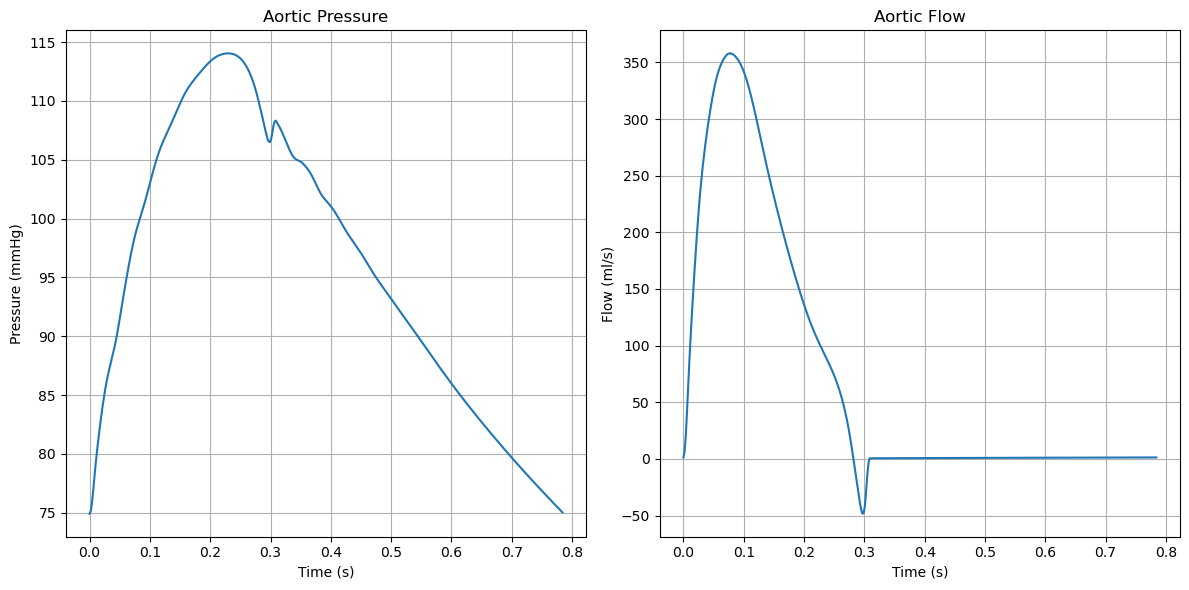

In [6]:
systolic_blood_pressure = max(pressure)
diastolic_blood_pressure = min(pressure)
pulse_pressure = systolic_blood_pressure - diastolic_blood_pressure
print(f'Pulse pressure is {np.mean(pulse_pressure):.1f} mmHg')
#mean_aortic_pressure = 1/3*systolic_blood_pressure + 2/3*diastolic_blood_pressure

print(f'Mean pressure is {np.mean(pressure):.1f} mmHg and mean flow is {np.mean(flow):.1f} ml/s')
plot_pressure_and_flow(time,pressure,flow)


- Find the total peripheral resistance

In [7]:
SVR = np.mean(pressure)/np.mean(flow)
print(f'Total Peripheral Resistance: {SVR:.2f} mmHg·s/mL')
print(f'Total Peripheral Resistance (SI): {SVR*133/1e-6:.2e} Pa·s/m³')


print(mean_aortic_pressure//np.mean(flow))
#Check pvr of subject!!
pvr # 108800000 Pa*s/m3 corresponds to 0.816069365896101 mmHg*s/mL
print(f'pvr database: {pvr:.2e} in SI probably')
print((1/3*systolic_blood_pressure + 2/3*diastolic_blood_pressure)/np.mean(flow))

Total Peripheral Resistance: 1.32 mmHg·s/mL
Total Peripheral Resistance (SI): 1.76e+08 Pa·s/m³


NameError: name 'mean_aortic_pressure' is not defined

# Calculate input impedance

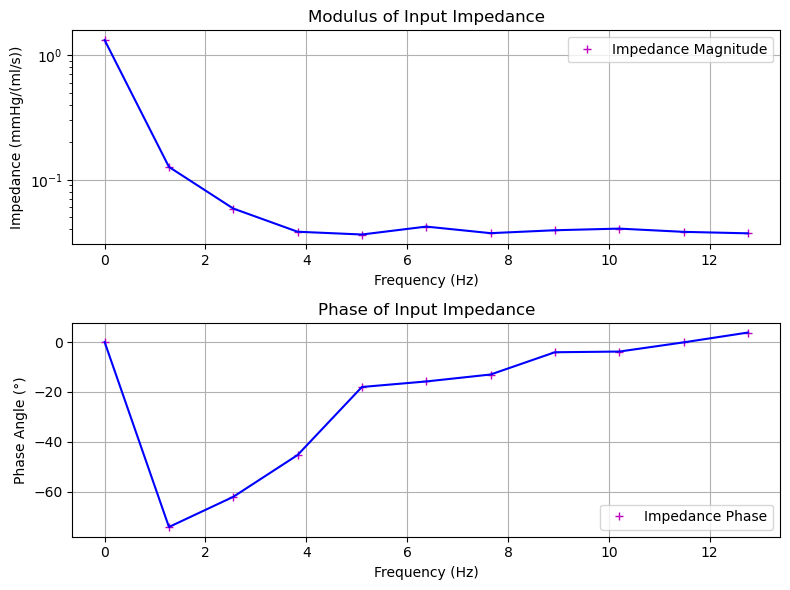


Harmonic    Frequency (Hz)    Modulus    Phase (°)
---------------------------------------------------
1         0.00000           1.32156     0.00000   
2         1.27551           0.12682     -74.17396 
3         2.55102           0.05878     -62.07569 
4         3.82653           0.03829     -45.31688 
5         5.10204           0.03638     -18.03083 
6         6.37755           0.04210     -15.81697 
7         7.65306           0.03730     -13.03153 
8         8.92857           0.03935     -4.10622  
9         10.20408          0.04056     -3.83257  
10        11.47959          0.03821     -0.14874  
11        12.75510          0.03717     3.79065   


In [ ]:
_ = calculate_input_impedance(time,pressure,flow)


# Calculate characteristic impedance

In [ ]:
_ = calculate_characteristic_impedance(time,pressure,flow)

Zc = 0.0386


In [ ]:
# ToDo check difference of Zc
# ToDo add time domain. what is the expected difference?

# Estimate compliance using the pulse pressure method (2-element Windkessel)


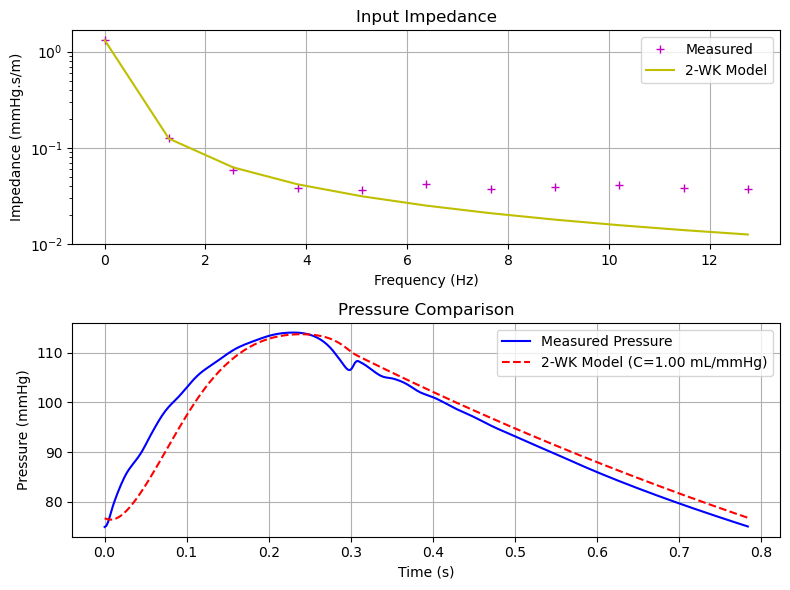

WK2 Compliance: 1.00 mL/mmHg
True Pulse Pressure: 39.13 mmHg, 2-WK Pulse Pressure: 37.31 mmHg


In [8]:
#from scipy.optimize import minimize_scalar

_ = calculate_compliance_using_PPM(time, pressure, flow, C_WK2_init=1.0)


- Now change the initial guess for the compliance (`C_WK2_init`). What trend do you observe for the estimated PP?

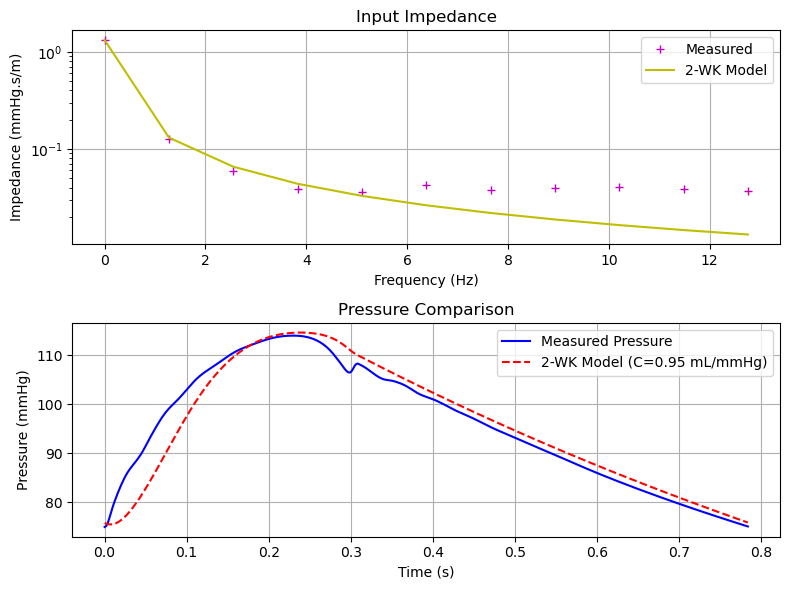

WK2 Compliance: 0.95 mL/mmHg
True Pulse Pressure: 39.13 mmHg, 2-WK Pulse Pressure: 39.22 mmHg


In [ ]:
_ = calculate_compliance_using_PPM(time, pressure, flow, C_WK2_init=0.95)

iv) Fit an exponential to the diastolic portion of the aortic pressure waveform

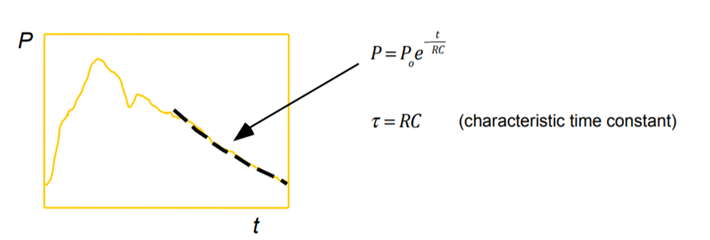

In [11]:
Zc = calculate_characteristic_impedance(time, pressure, flow, show=False)

Zc = 0.0386


# Fit a 3-element Windkessel model

Zc = 0.0386


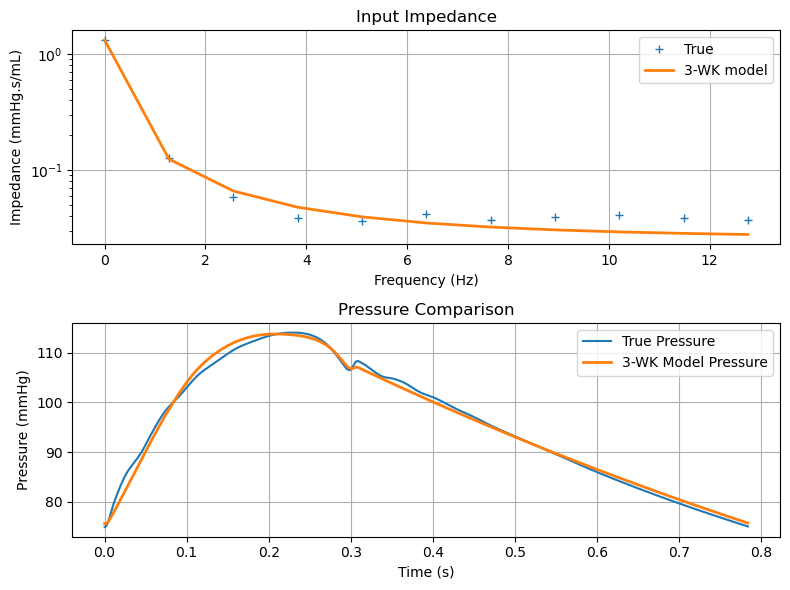


Estimated R: 1.2966 mmHg·s/mL, Zc: 0.0250 mmHg·s/mL, 3-WK C: 1.0401 mL/mmHg


In [9]:
_ = wk3(time, pressure, flow)

# Calculate the Pulse Wave Velocity (PWV)

In [12]:
mean_area = np.mean(area)
rho = 1060  # blood density in kg/m³
# Step (ii): Calculate pulse wave velocity
PWV = calculate_pwv(rho, mean_area, Zc)

PWV = 6.81
